In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('data.csv')
df.drop(columns=['Unnamed: 32'], errors='ignore', inplace=True)
if 'Diagnosis' in df.columns:
    df.rename(columns={'Diagnosis': 'diagnosis'}, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df.dropna(inplace=True)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, roc_auc_score,
    roc_curve
)

In [9]:
x=df.drop('diagnosis', axis=1)
y=df['diagnosis']
x_train, x_test, y_train, y_test = train_test_split(
 x, y, test_size=0.2, stratify=y, random_state=42
)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [11]:
model=LogisticRegression()
model.fit(x_train_scaled, y_train)
y_pred=model.predict(x_test_scaled)
y_prob=model.predict_proba(x_test_scaled)[:, 1]

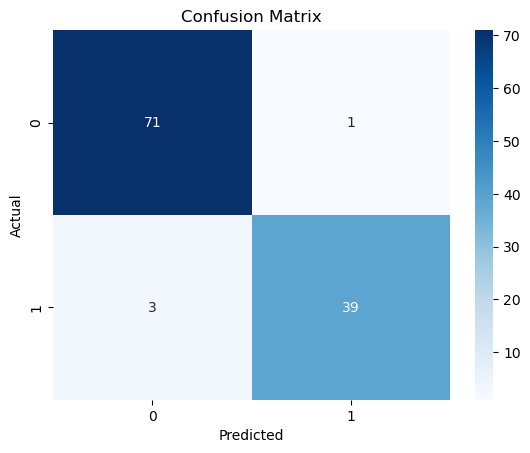

In [13]:
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
print(f"precision: {precision_score(y_test, y_pred):.3f}")
print(f"recall:    {recall_score(y_test, y_pred):.3f}")
print(f"ric-auc:   {roc_auc_score(y_test, y_prob):.3f}")

precision: 0.975
recall:    0.929
ric-auc:   0.996


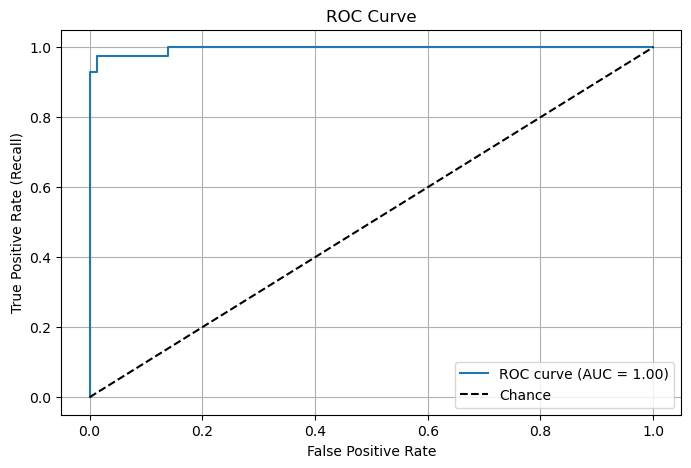

In [17]:
fpr,tpr,thresholds=roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
custom_threshold=0.3
y_custom=(y_prob>=custom_threshold).astype(int)
cm_custom=confusion_matrix(y_test, y_custom)

print("\ncustom threshold (0.3) Confusion Matrix:")
print(cm_custom)
print("precision:", precision_score(y_test, y_custom))
print("recall:   ", recall_score(y_test, y_custom))




custom threshold (0.3) Confusion Matrix:
[[71  1]
 [ 1 41]]
precision: 0.9761904761904762
recall:    0.9761904761904762


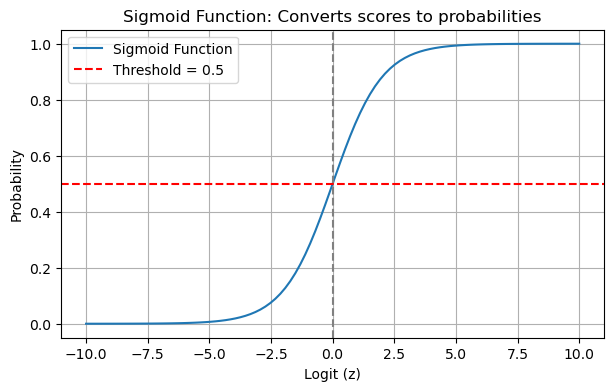

In [21]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
sig = sigmoid(z)

plt.figure(figsize=(7, 4))
plt.plot(z, sig, label="Sigmoid Function")
plt.axvline(0, color='gray', linestyle='--')
plt.axhline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.title("Sigmoid Function: Converts scores to probabilities")
plt.xlabel("Logit (z)")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()